# KMeans 第五课：标准化与 K 值选择

K-means 有两个非常实际的问题：

```text
不同特征量纲不一致怎么办？
K 到底应该取多少？
```

这一课学习标准化、肘部法和轮廓系数，并说明为什么指标不能代替业务判断。

In [1]:
import os

# sklearn 1.7.x 在 Windows + MKL 的小数据集上建议限制 OpenMP 线程数
os.environ["OMP_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

np.set_printoptions(precision=3, suppress=True)

from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## 1. 特征尺度为什么会改变聚类？

欧氏距离：

$$
d(x,\mu)=\sqrt{\sum_j(x_j-\mu_j)^2}
$$

如果一列范围是 `0~10`，另一列范围是 `0~100000`，第二列的差值平方会支配总距离。

这不代表第二列一定更重要，只代表它的计量单位更大。

In [2]:
X_base, _ = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=0.75,
    random_state=22,
)

# 人为把第二个特征放大 100 倍，模拟量纲不一致
X_unscaled = X_base.copy()
X_unscaled[:, 1] *= 100

print("两个特征的标准差:", X_unscaled.std(axis=0))

两个特征的标准差: [  2.047 408.342]


## 2. 使用 StandardScaler

$$
z=\frac{x-\mu}{\sigma}
$$

标准化后，每列均值约为 0、标准差约为 1，使各特征在距离计算中处于可比较尺度。

但要注意：标准化不是永远正确。如果某些特征按业务本来就应该具有更高权重，需要显式设计权重，而不是机械处理。

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unscaled)

print("标准化后均值:", X_scaled.mean(axis=0))
print("标准化后标准差:", X_scaled.std(axis=0))

标准化后均值: [-0. -0.]
标准化后标准差: [1. 1.]


## 3. 肘部法

对多个候选 `K` 分别训练模型，记录 `inertia_`：

```text
K 增大 -> inertia 必然不升
```

寻找下降速度明显变缓的转折点，形状像手臂的肘部，因此叫肘部法。

肘部法是启发式方法：有些数据没有清晰肘部，此时不能硬猜。

In [4]:
candidate_k = range(2, 9)
inertias = []
silhouette_scores = []

for k in candidate_k:
    candidate_model = KMeans(n_clusters=k, random_state=22, n_init=10)
    candidate_labels = candidate_model.fit_predict(X_scaled)
    inertias.append(candidate_model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, candidate_labels))

for k, inertia in zip(candidate_k, inertias):
    print(f"K={k}: inertia={inertia:.2f}")

K=2: inertia=250.24
K=3: inertia=100.53
K=4: inertia=65.92
K=5: inertia=56.06
K=6: inertia=46.58
K=7: inertia=39.45
K=8: inertia=32.85


## 4. 轮廓系数

对样本 $i$：

- $a(i)$：它与同簇其他样本的平均距离；
- $b(i)$：它与最近其他簇样本的平均距离。

$$
s(i)=\frac{b(i)-a(i)}{\max(a(i),b(i))}
$$

取值解释：

```text
接近 1  -> 同簇紧密、与其他簇分离较好
接近 0  -> 位于簇边界附近
小于 0  -> 可能被分错簇
```

`silhouette_score` 返回所有样本轮廓系数的平均值，只适用于至少 2 个簇且少于样本数的情况。

In [5]:
for k, score in zip(candidate_k, silhouette_scores):
    print(f"K={k}: silhouette={score:.4f}")

best_k = list(candidate_k)[int(np.argmax(silhouette_scores))]
print("本数据轮廓系数最高的 K:", best_k)

K=2: silhouette=0.5691
K=3: silhouette=0.5969
K=4: silhouette=0.5546
K=5: silhouette=0.4828
K=6: silhouette=0.4623
K=7: silhouette=0.4204
K=8: silhouette=0.3996
本数据轮廓系数最高的 K: 3


## 5. 把两个指标放在一起看

```text
肘部法     -> 看继续增加 K 是否还带来明显收益
轮廓系数   -> 看簇内紧密和簇间分离的综合效果
业务解释   -> 判断分组数量是否可理解、可行动、可稳定复现
```

三个维度应一起判断。

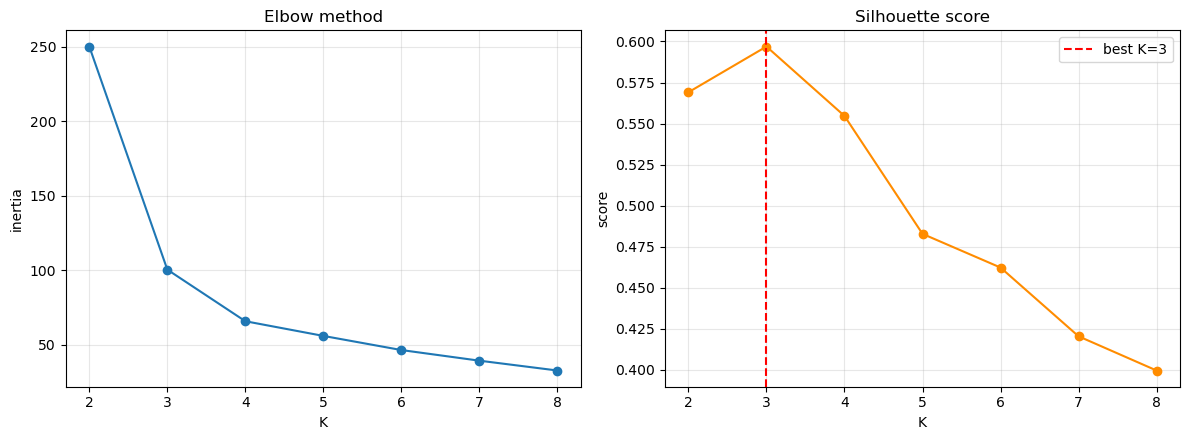

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(candidate_k), inertias, marker="o")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("inertia")
axes[0].grid(alpha=0.3)

axes[1].plot(list(candidate_k), silhouette_scores, marker="o", color="darkorange")
axes[1].axvline(best_k, color="red", linestyle="--", label=f"best K={best_k}")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("score")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 使用选定的 K 训练最终模型

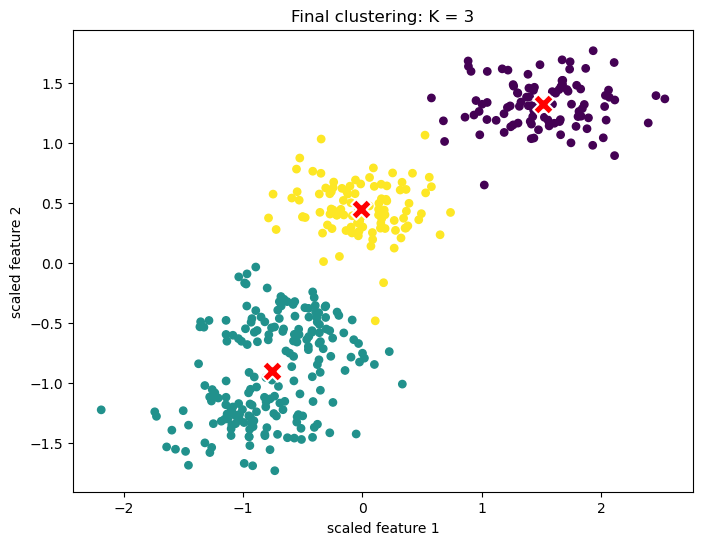

In [7]:
final_model = KMeans(n_clusters=best_k, random_state=22, n_init=10)
final_labels = final_model.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=final_labels, cmap="viridis", s=28)
plt.scatter(
    final_model.cluster_centers_[:, 0], final_model.cluster_centers_[:, 1],
    c="red", marker="X", s=220, edgecolors="white", linewidths=1.5,
)
plt.title(f"Final clustering: K = {best_k}")
plt.xlabel("scaled feature 1")
plt.ylabel("scaled feature 2")
plt.show()

## 7. 无监督学习为什么不能照搬交叉验证准确率？

普通分类准确率需要真实标签 `y_true`，但真实聚类任务通常没有 `y`。

因此 K-means 评估常分三层：

1. **内部指标**：inertia、轮廓系数，只看数据与分组；
2. **稳定性**：更换样本或随机种子后，分组是否接近；
3. **外部价值**：簇是否可解释、能否支持实际决策。

如果数据恰好有真实标签，只能将其用于事后评估，不能假装普通分类准确率就是聚类训练目标。

## 8. 本课小结

- 距离模型对特征尺度敏感；
- 标准化参数必须复用于新数据；
- inertia 随 `K` 增大而下降，不能独立选择 `K`；
- 肘部法看边际收益是否明显变小；
- 轮廓系数兼顾簇内紧密与簇间分离；
- 最终 `K` 还要结合稳定性和业务意义。

下一课学习初始化、异常值和 K-means 的适用边界。